# Exploratory Data Analysis

Perform exploratory data analysis on NBA set.  Moved to separte notebook to avoid running everytime data is loaded.

Call jupyter notebook to load data

In [53]:
%run ./Load_NBA_Dataset.ipynb

In [27]:
# Imports

import seaborn as sns
import polars as pl
import matplotlib.pyplot as plt
from itertools import product
import scipy.stats as ss


## Data Checks

In [15]:
df_merged.columns

['GRID_TYPE',
 'GAME_ID',
 'GAME_EVENT_ID',
 'PLAYER_ID',
 'PLAYER_NAME',
 'TEAM_ID',
 'TEAM_NAME',
 'PERIOD',
 'MINUTES_REMAINING',
 'SECONDS_REMAINING',
 'EVENT_TYPE',
 'ACTION_TYPE',
 'SHOT_TYPE',
 'SHOT_ZONE_BASIC',
 'SHOT_ZONE_AREA',
 'SHOT_ZONE_RANGE',
 'SHOT_DISTANCE',
 'LOC_X',
 'LOC_Y',
 'SHOT_ATTEMPTED_FLAG',
 'SHOT_MADE_FLAG',
 'GAME_DATE',
 'HTM',
 'VTM',
 'clock',
 'timeActual',
 'period',
 'periodType',
 'actionType',
 'subType',
 'qualifiers',
 'personId',
 'x',
 'y',
 'possession',
 'scoreHome',
 'scoreAway',
 'edited',
 'orderNumber',
 'isTargetScoreLastPeriod',
 'xLegacy',
 'yLegacy',
 'isFieldGoal',
 'side',
 'description',
 'personIdsFilter',
 'teamId',
 'teamTricode',
 'descriptor',
 'jumpBallRecoveredName',
 'jumpBallRecoverdPersonId',
 'playerName',
 'playerNameI',
 'jumpBallWonPlayerName',
 'jumpBallWonPersonId',
 'jumpBallLostPlayerName',
 'jumpBallLostPersonId',
 'area',
 'areaDetail',
 'shotDistance',
 'shotResult',
 'blockPlayerName',
 'blockPersonId',
 'sho

In [13]:
df_merged.describe()

statistic,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,…,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,Record_Id,game_date,time_remaining,score_margin_after,score_change,relative_margin_before
str,str,f64,f64,f64,str,f64,str,f64,f64,f64,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,f64,str,str,str,str,f64,f64,f64,f64,f64,…,str,str,f64,str,str,str,f64,str,f64,str,str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,f64,f64,f64,f64,str,f64,str,str,str,f64,f64,f64
"""count""","""219527""",219527.0,219527.0,219527.0,"""219527""",219527.0,"""219527""",219527.0,219527.0,219527.0,"""219527""","""219527""","""219527""","""219527""","""219527""","""219527""",219527.0,219527.0,219527.0,219527.0,219527.0,219527.0,"""219527""","""219527""","""219524""","""219524""",219524.0,"""219524""","""219524""","""219524""","""219524""",219524.0,219524.0,219524.0,219524.0,219524.0,…,"""150690""","""0""",0.0,"""219524""","""219524""","""0""",0.0,"""0""",0.0,"""219523""","""219524""",219524.0,"""219524""","""11993""",11993.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,102566.0,"""65312""",65312.0,65312.0,0.0,0.0,"""0""",0.0,"""219527""","""219527""","""219527""",219524.0,219527.0,219524.0
"""null_count""","""0""",0.0,0.0,0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""3""","""3""",3.0,"""3""","""3""","""3""","""3""",3.0,3.0,3.0,3.0,3.0,…,"""68837""","""219527""",219527.0,"""3""","""3""","""219527""",219527.0,"""219527""",219527.0,"""4""","""3""",3.0,"""3""","""207534""",207534.0,219527.0,219527.0,219527.0,219527.0,219527.0,219527.0,"""219527""",219527.0,116961.0,"""154215""",154215.0,154215.0,219527.0,219527.0,"""219527""",219527.0,"""0""","""0""","""0""",3.0,0.0,3.0
"""mean""",null,2.2401e7,330.567493,1.3752e6,null,1.6106e9,null,2.480843,5.385274,28.853617,null,null,null,null,null,null,14.003635,-2.252251,97.446464,1.0,0.467214,2.0247e7,null,null,null,"""2025-01-19 00:54:21.708397+00:…",2.480836,null,null,null,null,1.3752e6,49.833238,49.493792,1.6106e9,56.89305,…,null,null,null,null,null,null,null,null,null,null,null,14.484858,null,null,1.3805e6,null,null,null,null,null,null,null,null,9.854425,null,1.3309e6,3.121279,null,null,null,null,null,"""2025-01-17 23:13:31.532066""","""0:05:51.970044""",0.873326,1.086135,-0.637971
"""std""",null,354.580103,199.058742,550394.782499,null,8.705154,null,1.127515,3.450603,17.407554,null,null,null,null,null,null,10.698021,116.722689,96.627021,0.0,0.498925,4443.34033,null,null,null,null,1.127517,null,null,null,null,550386.873113,35.563115,23.342663,8.70513,34.286788,…,null,null,null,null,null,null,null,null,null,null,null,10.714503,null,null,545722.906185,null,null,null,null,null,null,null,null,7.306994,null,585964.051679,2.412323,null,null,null,null,null,null,null,11.84318,1.203209,11.799668
"""min""","""Shot Chart Detail""",2.2400001e7,4.0,2544.0,"""A.J. Lawson""",1.6106e9,"""Atlanta Hawks""",1.0,0.0,0.0,"""Made Shot""","""Alley Oop Dunk Shot""","""2PT Field Goal""","""Above the Break 3""","""Back Court(BC)""","""16-24 ft.""",0.0,-250.0,-52.0,1.0,0.0,2.0241022e7,"""ATL""","""ATL""","""PT00M00.00S""","""2024-10-22 23:36:07.500000+00:…",1.0,"""OVERTIME"

In [5]:
# Check merge logic correct & identify discrepancies

# Display Team ID discrepancies
team_discrepancies = df_merged.filter(pl.col("TEAM_ID") != pl.col("teamId"))
team_discrepancies

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,…,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,Record_Id,game_date,time_remaining,score_margin_after,score_change,relative_margin_before
str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,"datetime[μs, UTC]",i64,str,str,str,str,i64,f64,f64,i64,i64,i64,…,str,str,i64,str,str,str,i64,str,i64,str,str,f64,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,i64,str,i64,str,datetime[μs],duration[μs],i64,i32,i64


In [6]:
# Display Player ID discrepancies
player_discrepancies = df_merged.filter(pl.col("PLAYER_ID") != pl.col("personId"))
player_discrepancies

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,…,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,Record_Id,game_date,time_remaining,score_margin_after,score_change,relative_margin_before
str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,"datetime[μs, UTC]",i64,str,str,str,str,i64,f64,f64,i64,i64,i64,…,str,str,i64,str,str,str,i64,str,i64,str,str,f64,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,i64,str,i64,str,datetime[μs],duration[μs],i64,i32,i64
"""Shot Chart Detail""",22400912,368,1641878,"""Damion Baugh""",1610612766,"""Charlotte Hornets""",3,9,46,"""Missed Shot""","""Driving Finger Roll Layup Shot""","""2PT Field Goal""","""Restricted Area""","""Center(C)""","""Less Than 8 ft.""",1,13,5,1,0,20250308,"""CHA""","""BKN""","""PT09M46.00S""",2025-03-09 00:26:20.600 UTC,3,"""REGULAR""","""2pt""","""Layup""","""pointsinthepaint""",1641733,6.126807,47.303922,1610612766,48,63,…,"""driving finger roll""",null,null,"""Smith Jr.""","""N. Smith Jr.""",null,null,null,null,"""Restricted Area""","""0-8 Center""",1.44,"""Missed""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""22400912_368""",2025-03-08 00:00:00,9m 46s,-15,0,-15
"""Shot Chart Detail""",22400783,512,1642377,"""Jaylen Wells""",1610612763,"""Memphis Grizzlies""",3,0,46,"""Missed Shot""","""Running Jump Shot""","""3PT Field Goal""","""Left Corner 3""","""Left Side(L)""","""24+ ft.""",23,-232,18,1,0,20250212,"""LAC""","""MEM""","""PT00M46.00S""",2025-02-13 05:18:30.200 UTC,3,"""REGULAR""","""3pt""","""Jump Shot""","""fastbreak""",1630590,7.467559,96.300551,1610612763,102,82,…,"""running""",null,null,"""Pippen Jr.""","""S. Pippen Jr.""",null,null,null,null,"""Left Corner 3""","""24+ Left""",23.22,"""Missed""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""22400783_512""",2025-02-12 00:00:00,46s,20,0,-20
"""Shot Chart Detail""",22400065,367,1629639,"""Tyler Herro""",1610612748,"""Miami Heat""",2,0,51,"""Missed Shot""","""Driving Layup Shot""","""2PT Field Goal""","""Restricted Area""","""Center(C)""","""Less Than 8 ft.""",1,16,-4,1,0,20241023,"""MIA""","""ORL""","""PT00M51.30S""",2024-10-24 00:44:04.300 UTC,2,"""REGULAR""","""2pt""","""Layup""","""pointsinthepaint""",1631107,5.206965,46.813725,1610612748,54,55,…,"""driving""",null,null,"""Jović""","""N. Jović""",null,null,null,null,"""Restricted Area""","""0-8 Center""",1.63,"""Missed""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""22400065_367""",2024-10-23 00:00:00,51s,-1,0,-1
"""Shot Chart Detail""",22401102,710,1629638,"""Nickeil Alexander-Walker""",1610612750,"""Minnesota Timberwolves""",5,0,0,"""Missed Shot""","""Tip Layup Shot""","""2PT Field Goal""","""Restricted Area""","""Center(C)""","""Less Than 8 ft.""",2,-16,24,1,0,20250401,"""DEN""","""MIN""","""PT00M00.20S""",2025-04-02 04:54:01.100 UTC,5,"""OVERTIME""","""2pt""","""Layup""","""pointsinthepaint, 2ndchance""",1630183,8.097898,53.186275,1610612750,125,125,…,"""tip""",null,null,"""McDaniels""","""J. McDaniels""",null,null,null,null,"""Restricted Area""","""0-8 Center""",2.85,"""Missed""

In [7]:
# Display Player ID discrepancies
possession_discrepancies = df_merged.filter(pl.col("TEAM_ID") != pl.col("possession"))
possession_discrepancies

GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,…,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,blockPlayerName,blockPersonId,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,officialId,turnoverTotal,stealPlayerName,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,Record_Id,game_date,time_remaining,score_margin_after,score_change,relative_margin_before
str,i64,i64,i64,str,i64,str,i64,i64,i64,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,"datetime[μs, UTC]",i64,str,str,str,str,i64,f64,f64,i64,i64,i64,…,str,str,i64,str,str,str,i64,str,i64,str,str,f64,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,i64,str,i64,str,datetime[μs],duration[μs],i64,i32,i64


In [49]:
# Confirm coordinate systems match
df_coordinates = df_merged.select('SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'x', 'y')

# Convert from normalised coordinates with datum at top left to centre-line datum & measurements in feet * 10
df_coordinates = df_coordinates.with_columns(
    (250 - pl.col('y')*0.50*10).round(0).cast(pl.Int32).alias('x_test'), 
    (pl.col('x')*0.94*10 - 52.5).round(0).cast(pl.Int32).alias('y_test')
)
df_coordinates

SHOT_DISTANCE,LOC_X,LOC_Y,x,y,x_test,y_test
i64,i64,i64,f64,f64,i32,i32
26,-168,205,27.414586,83.578431,-168,205
13,-136,-1,5.469777,77.205882,-136,-1
25,157,203,27.151774,18.627451,157,203
25,-176,184,25.180683,85.294118,-176,184
2,-25,8,6.438896,55.005362,-25,8
…,…,…,…,…,…,…
1,15,1,5.732589,47.058824,15,1
32,183,267,33.984888,13.480392,183,267
23,229,32,9.01774,4.166667,229,32


## Data Quality

In [57]:
df_independent

PERIOD,LOC_X,LOC_Y,pointsTotal,relative_margin_before,shotDistance,time_remaining
i64,i64,i64,i64,i64,f64,duration[μs]
1,-168,205,0,0,26.51,11m 43s
1,-136,-1,0,0,13.6,11m 38s
1,157,203,3,0,25.63,10m 50s
1,-176,184,0,0,25.51,9m 47s
1,-25,8,2,0,2.62,9m 44s
…,…,…,…,…,…,…
4,15,1,18,-17,1.48,3m 14s
4,183,267,0,-18,32.35,2m 53s
4,229,32,14,-21,23.15,2m 11s


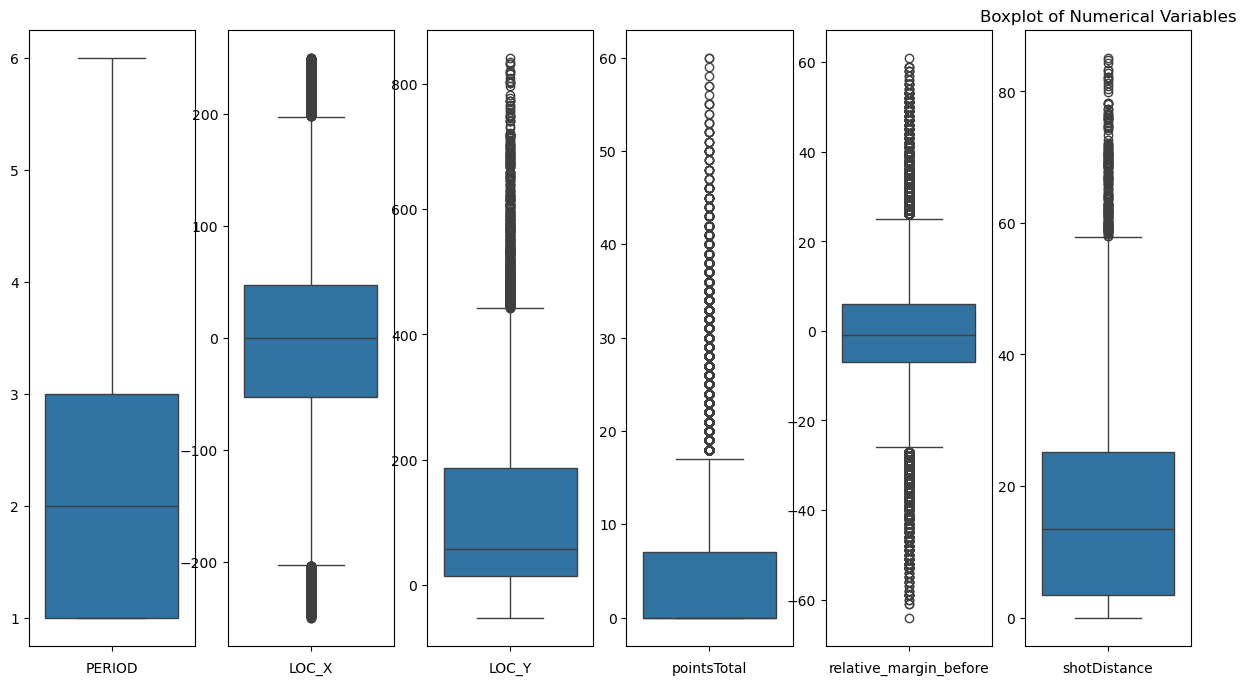

In [ ]:
df_independent = df_numerical.drop('SHOT_MADE_FLAG', 'time_remaining')

# Generate box plots of data.
fig, axes = plt.subplots(1, 6, figsize=(15,8))
plt.title('Boxplot of Numerical Variables')

column_names = df_independent.columns

for pos, name in enumerate(column_names):
    sns.boxplot(data=df_independent[name], orient='v', ax=axes[pos])
    axes[pos].set_xlabel(name)



## Distribution of Variables

## Correlation

Explore correlation between numeric variables

Text(0.5, 1.0, 'Dependent variable (shot success) correlation with independent numerical variables')

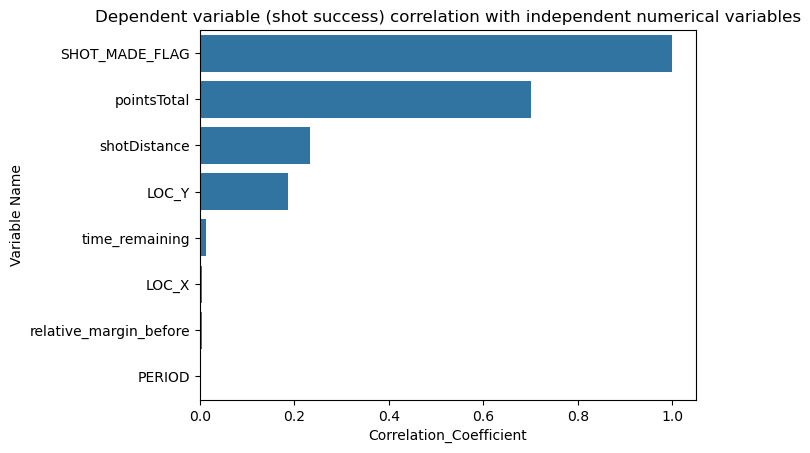

In [14]:
# Check pearson correlation between columns containing numeric values
temp2 = zip(df_model.columns, pl.Series(df_model.corr().select('SHOT_MADE_FLAG')
    ).abs().to_list())

# Sort descending largest to smallest
df_correlation = pd.DataFrame(temp2, columns=['Variable Name', 'Correlation_Coefficient'])
df_correlation.sort_values('Correlation_Coefficient', axis=0, ascending=False, inplace=True)

# Plot as barplot
sns.barplot(df_correlation, x='Correlation_Coefficient', y='Variable Name', orient='h')
plt.title("Dependent variable (shot success) correlation with independent numerical variables")

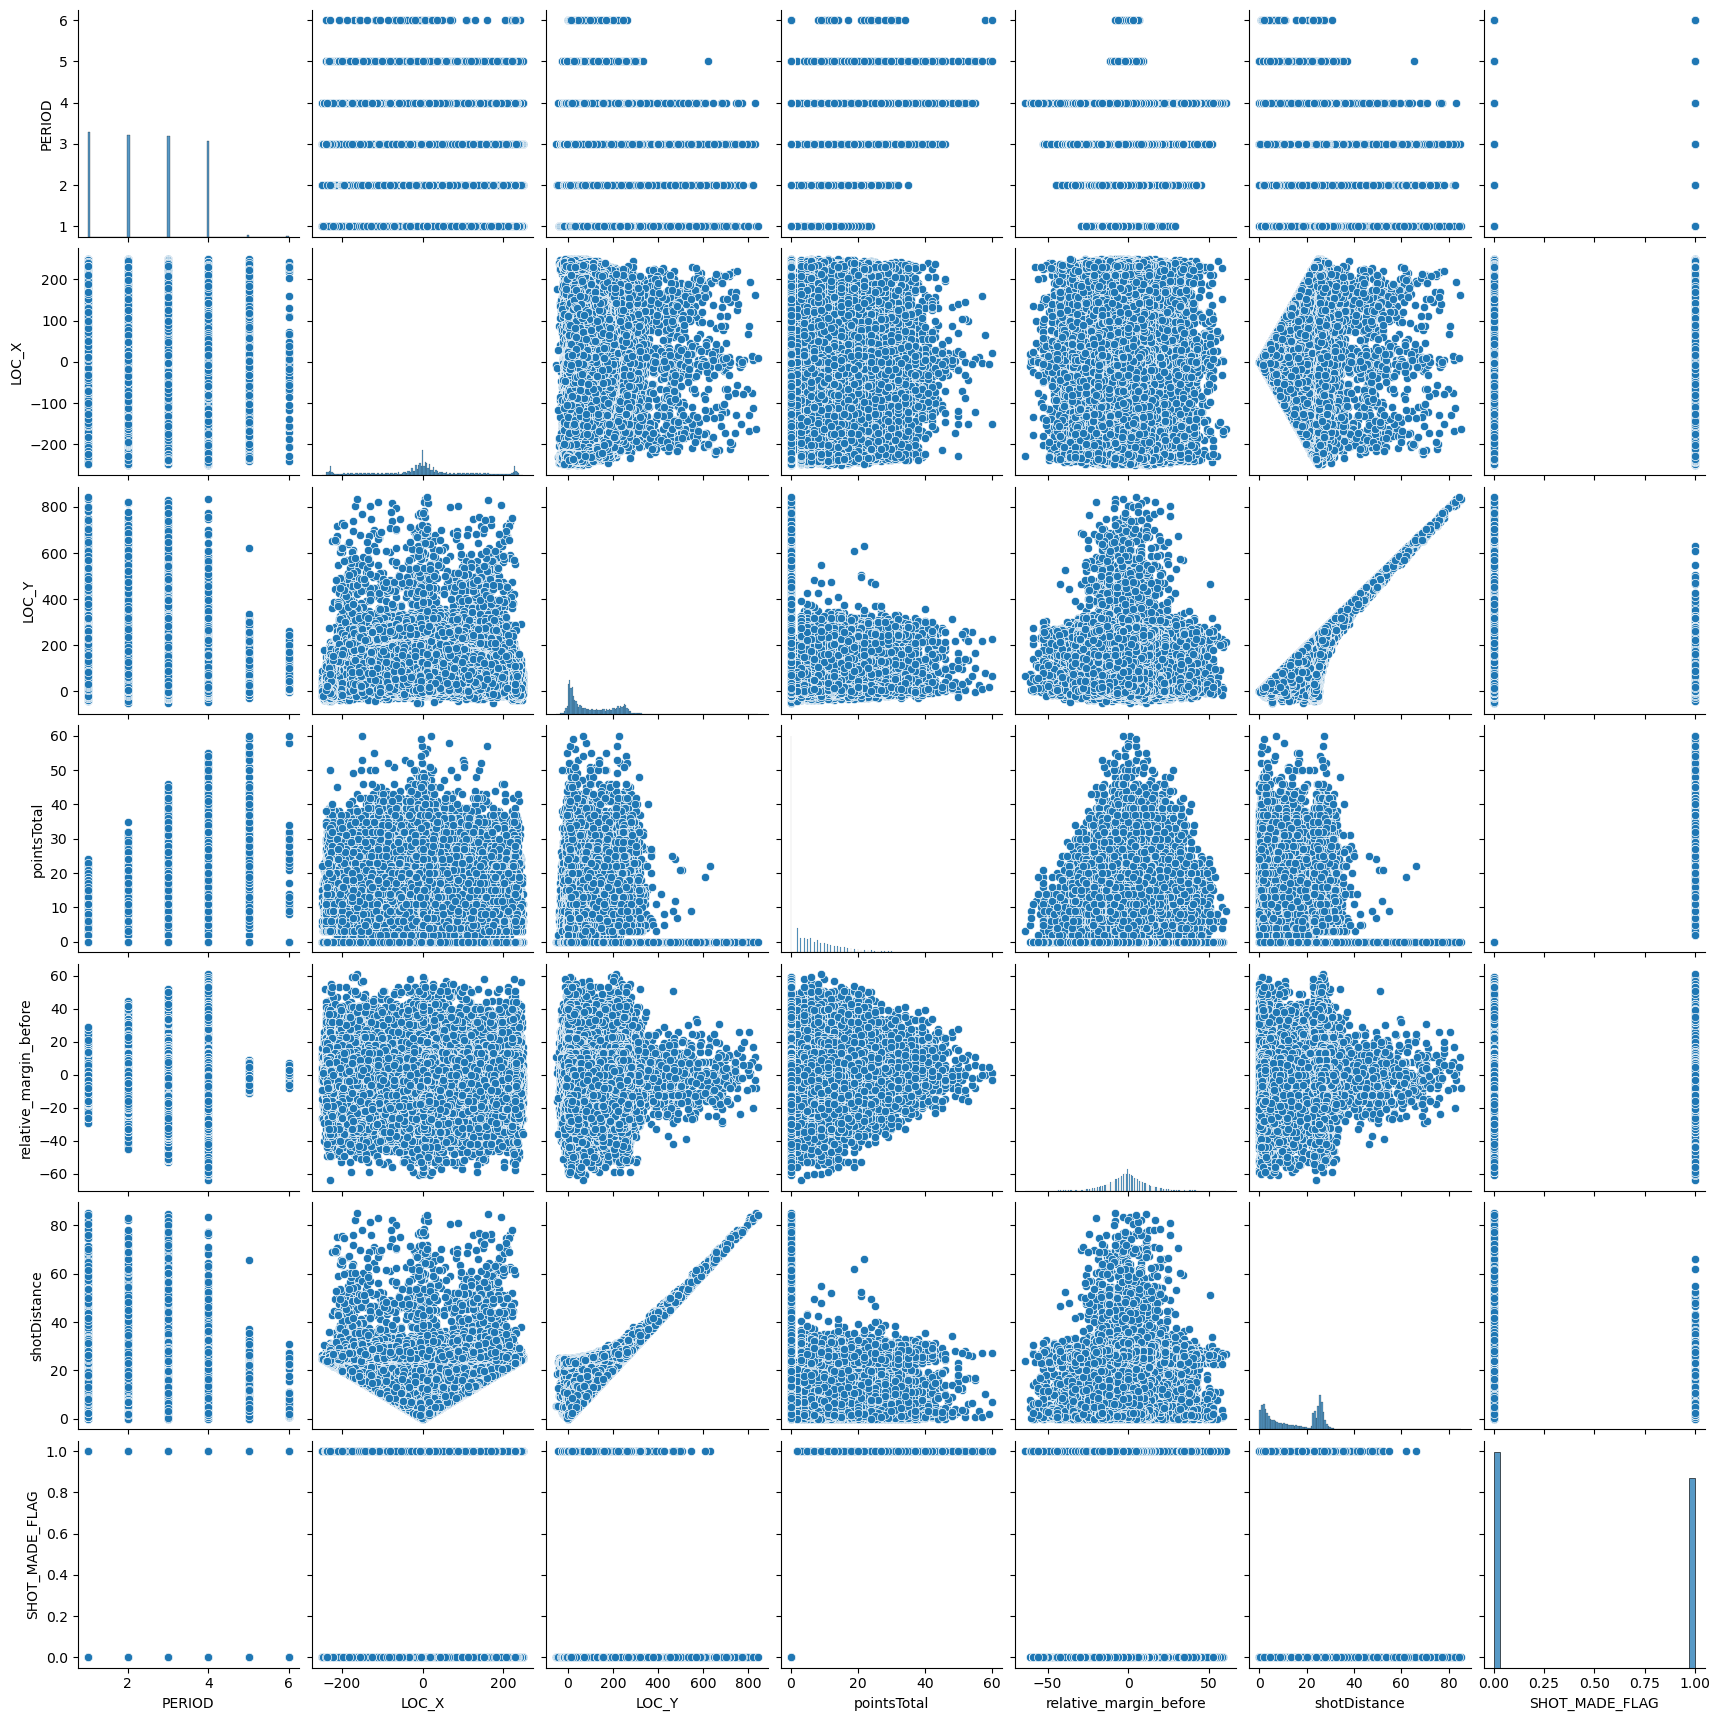

In [4]:
sns.pairplot(df)

## Correlation - Categorical variables

Explore multicollinearity & variable independence

In [ ]:
pddf_categorical = df_categorical.to_pandas()

column_names = pddf_categorical.columns

# Generate all possible pairwise combinations of columns
pairwise = list(product(column_names, column_names))
print(pairwise)


[('ACTION_TYPE', 'ACTION_TYPE'), ('ACTION_TYPE', 'isHomeTeam'), ('ACTION_TYPE', 'PLAYER_ID'), ('ACTION_TYPE', 'SHOT_ZONE_BASIC'), ('ACTION_TYPE', 'SHOT_ZONE_AREA'), ('ACTION_TYPE', 'SHOT_ZONE_RANGE'), ('ACTION_TYPE', 'subType'), ('ACTION_TYPE', 'SHOT_MADE_FLAG'), ('isHomeTeam', 'ACTION_TYPE'), ('isHomeTeam', 'isHomeTeam'), ('isHomeTeam', 'PLAYER_ID'), ('isHomeTeam', 'SHOT_ZONE_BASIC'), ('isHomeTeam', 'SHOT_ZONE_AREA'), ('isHomeTeam', 'SHOT_ZONE_RANGE'), ('isHomeTeam', 'subType'), ('isHomeTeam', 'SHOT_MADE_FLAG'), ('PLAYER_ID', 'ACTION_TYPE'), ('PLAYER_ID', 'isHomeTeam'), ('PLAYER_ID', 'PLAYER_ID'), ('PLAYER_ID', 'SHOT_ZONE_BASIC'), ('PLAYER_ID', 'SHOT_ZONE_AREA'), ('PLAYER_ID', 'SHOT_ZONE_RANGE'), ('PLAYER_ID', 'subType'), ('PLAYER_ID', 'SHOT_MADE_FLAG'), ('SHOT_ZONE_BASIC', 'ACTION_TYPE'), ('SHOT_ZONE_BASIC', 'isHomeTeam'), ('SHOT_ZONE_BASIC', 'PLAYER_ID'), ('SHOT_ZONE_BASIC', 'SHOT_ZONE_BASIC'), ('SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA'), ('SHOT_ZONE_BASIC', 'SHOT_ZONE_RANGE'), ('SHOT_ZON

In [ ]:

output = []

# For each tuple (permutation), calculate chi2
for a in pairwise:
    if a[0] != a[1]:
        contingency_table = pd.crosstab(pddf_categorical[a[0]], pddf_categorical[a[1]])
        chi2_value = ss.chi2_contingency(contingency_table).pvalue
        output.append(
            (a[0],
            a[1],
            chi2_value)
        )

chi_test_output = pd.DataFrame(output, columns = ['var1', 'var2', 'coeff'])
                                                       
## Using pivot function to convert the above DataFrame into a crosstab
chi_test_output = chi_test_output.pivot(index='var1', columns='var2', values='coeff')

chi_test_output

var2,ACTION_TYPE,PLAYER_ID,SHOT_MADE_FLAG,SHOT_ZONE_AREA,SHOT_ZONE_BASIC,SHOT_ZONE_RANGE,isHomeTeam,subType
var1,,,,,,,,
ACTION_TYPE,NaN,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,9.463471e-09,0.000000e+00
PLAYER_ID,0.000000e+00,NaN,0.000000,0.000000,0.000000e+00,0.000000e+00,1.237968e-267,0.000000e+00
SHOT_MADE_FLAG,0.000000e+00,0.000000e+00,NaN,0.000000,0.000000e+00,0.000000e+00,6.744436e-03,0.000000e+00
SHOT_ZONE_AREA,0.000000e+00,0.000000e+00,0.000000,NaN,0.000000e+00,0.000000e+00,2.891104e-05,0.000000e+00
SHOT_ZONE_BASIC,0.000000e+00,0.000000e+00,0.000000,0.000000,NaN,0.000000e+00,3.447564e-08,0.000000e+00
SHOT_ZONE_RANGE,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,NaN,9.077376e-07,0.000000e+00
isHomeTeam,9.463471e-09,1.237968e-267,0.006744,0.000029,3.447564e-08,9.077376e-07,NaN,2.649511e-07
subType,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,2.649511e-07,NaN
